In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from Paramater_script import S2_graph_definite_N, plot_graph_on_sphere

In [2]:
# Helper functions
def get_average_degree(graph):
    degrees = dict(graph.degree())
    average_degree = sum(degrees.values()) / len(degrees)
    return average_degree

def get_average_clustering(graph):
    return nx.average_clustering(graph)

In [3]:
def run_mu_experiment(mu_values, N, beta, trials=5, loop=True):
    avg_degrees = []
    coords = []
    As = []
    for mu in mu_values:
        trial_degrees = []
        for _ in range(trials):
            A, _, coord = S2_graph_definite_N(N, beta, mu, return_coords=True, force_connected=loop)
            graph = nx.from_numpy_array(A) # Turn into graph
            trial_degree = get_average_degree(graph)
            trial_degrees.append(trial_degree)
        avg_degrees.append(np.mean(trial_degrees))
        coords.append(coord)
        As.append(A)
    A_low = As[0]
    coords_low = coords[0]
    A_high = As[-1]
    coords_high = coords[-1]
    return avg_degrees, A_low, coords_low, A_high, coords_high

In [6]:
my_mu_values = np.linspace(0.005, 0.05, 10) # Example mu values
avg_degrees, A_low, coords_low, A_high, coords_high = run_mu_experiment(my_mu_values, 200, 2.6, loop=False)
avg_degrees_l, A_low_l, coords_low_l, A_high_l, coords_high_l = run_mu_experiment(my_mu_values, 200, 2.6)

In [12]:
def run_beta_experiment(beta_values, N, mu, trials=5, loop=True):
    avg_clustering = []
    coords = []
    As = []
    for beta in beta_values:
        for _ in range(trials):
            trial_clustering = []
            A, _, coord = S2_graph_definite_N(N, beta, mu, return_coords=True, force_connected=loop)
            graph = nx.from_numpy_array(A) # Turn into graph
            trial_cluster = get_average_clustering(graph)
            trial_clustering.append(trial_cluster)
        avg_clustering.append(np.mean(trial_clustering))
        coords.append(coord)
        As.append(A)
    A_low = As[0]
    coords_low = coords[0]
    A_high = As[-1]
    coords_high = coords[-1]
    return avg_clustering, A_low, coords_low, A_high, coords_high

In [14]:
my_beta_values = np.linspace(1.0, 3.5, 10) # Example beta values
avg_clustering, A_low_beta, coords_low_beta, A_high_beta, coords_high_beta = run_beta_experiment(my_beta_values, 200, 0.0233, loop=False)
avg_clustering_l, A_low_beta_l, coords_low_beta_l, A_high_beta_l, coords_high_beta_l = run_beta_experiment(my_beta_values, 200, 0.0233)

In [7]:
def plot_parameter_sweep(x_values, y_values, x_label, y_label, title):
    """
    Generates a clean, scientific line plot for parameter sweeps.
    """
    # Create a new figure with a good aspect ratio
    plt.figure(figsize=(8, 5))

    # Plot the line with circular markers ('o') for each data point
    plt.plot(x_values, y_values, marker='o', linestyle='-', color='#1f77b4', markersize=6, linewidth=2)

    # Add labels and title
    plt.xlabel(x_label, fontsize=12)
    plt.ylabel(y_label, fontsize=12)
    plt.title(title, fontsize=14, pad=10)

    # Add a subtle grid to make reading values easier
    plt.grid(True, linestyle='--', alpha=0.7)

    # Adjust layout so labels don't get cut off
    plt.tight_layout()

    # Display the plot
    plt.savefig(f"{title.replace(' ', '_')}.pdf", dpi=300)  # Save the figure
    plt.show()

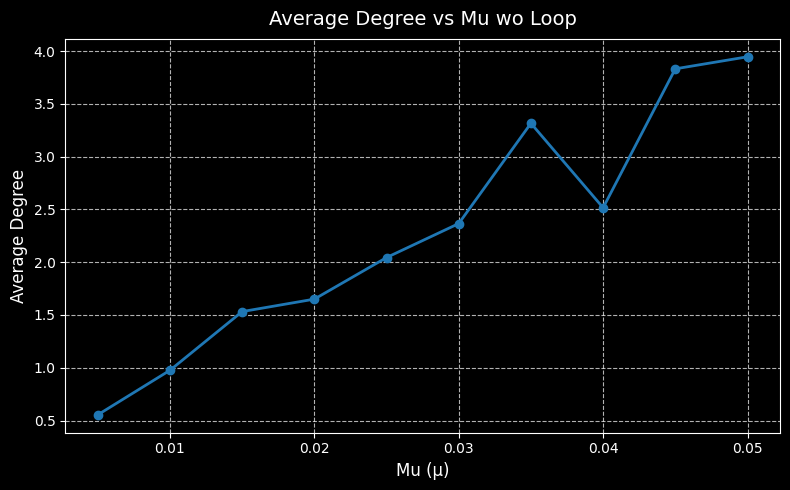

In [11]:
plot_parameter_sweep(my_mu_values, avg_degrees, 'Mu (μ)', 'Average Degree', 'Average Degree vs Mu wo Loop')

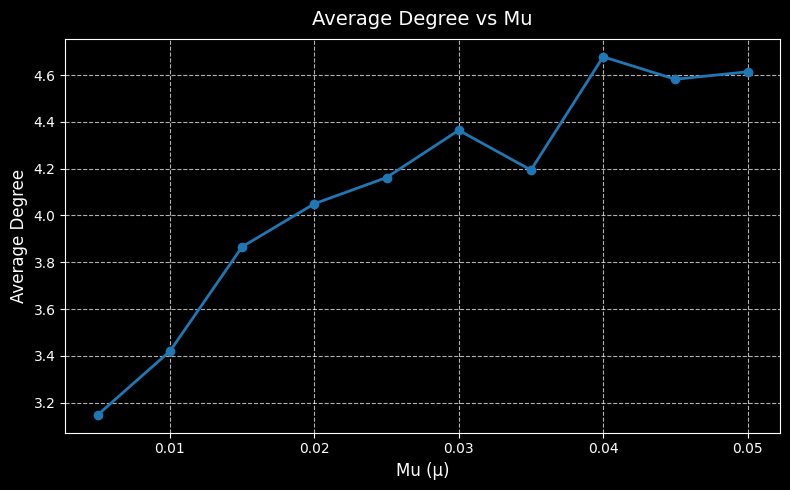

In [9]:
plot_parameter_sweep(my_mu_values, avg_degrees_l, 'Mu (μ)', 'Average Degree', 'Average Degree vs Mu')

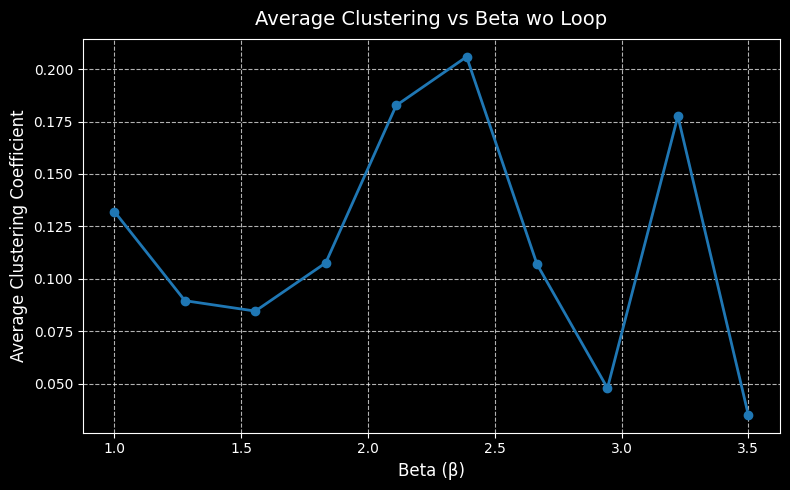

In [18]:
plot_parameter_sweep(my_beta_values, avg_clustering, 'Beta (β)', 'Average Clustering Coefficient', 'Average Clustering vs Beta wo Loop')

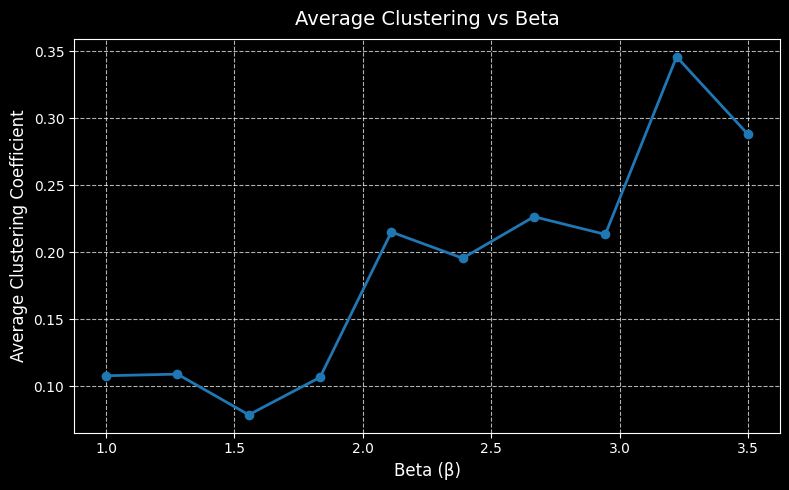

In [19]:
plot_parameter_sweep(my_beta_values, avg_clustering_l, 'Beta (β)', 'Average Clustering Coefficient', 'Average Clustering vs Beta')